# 🎧 Обнаружение дронов по аудиоданным

**ВКР: Разработка системы обнаружения и распознавания дронов (аудио-модуль)**

Подход: аудиозапись → мел-спектрограмма / MFCC → CNN → классификация

---

### Содержание
1. Установка и конфигурация
2. Загрузка датасетов
3. EDA — анализ аудиоданных
4. Извлечение признаков (Mel-спектрограммы, MFCC)
5. Подготовка данных (DataLoader)
6. Архитектура модели
7. Обучение
8. Оценка и визуализация
9. Сравнение моделей
10. Экспорт результатов

### Датасет
**DroneAudioDataset** (Al-Emadi et al.) — бинарная классификация:  
- `yes_drone` — звуки дронов Bebop, Mambo, Phantom  
- `unknown` — фоновые шумы, тишина, окружающая среда

---
## 1. Установка и конфигурация

In [1]:
!pip install -q librosa soundfile
# torch уже предустановлен на Kaggle

In [2]:
import os, sys, json, shutil, random, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm.auto import tqdm
from IPython.display import Audio, display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:  {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cpu
Device:  cpu


In [3]:
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================

WORK_DIR = Path('/kaggle/working')
DATA_DIR = WORK_DIR / 'audio_data'
VIZ_DIR = WORK_DIR / 'visualizations'
MODEL_DIR = WORK_DIR / 'models'

for d in [DATA_DIR, VIZ_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Аудио
SAMPLE_RATE = 16000
DURATION = 3.0
N_SAMPLES = int(SAMPLE_RATE * DURATION)

# Мел-спектрограмма
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
N_MFCC = 40

# Обучение
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

LABEL_NAMES = {0: 'no_drone', 1: 'drone'}

print('✅ Конфигурация готова')
print(f'   Сегмент: {DURATION}с @ {SAMPLE_RATE}Hz = {N_SAMPLES} сэмплов')
print(f'   Мел-спектрограмма: {N_MELS} полос, FFT={N_FFT}, hop={HOP_LENGTH}')

✅ Конфигурация готова
   Сегмент: 3.0с @ 16000Hz = 48000 сэмплов
   Мел-спектрограмма: 128 полос, FFT=2048, hop=512


---
## 2. Загрузка датасета

In [4]:
REPO_URL = 'https://github.com/saraalemadi/DroneAudioDataset.git'
DATASET_DIR = DATA_DIR / 'DroneAudioDataset'

if not DATASET_DIR.exists():
    print('⬇️  Клонирую DroneAudioDataset...')
    !git clone --depth 1 {REPO_URL} {DATASET_DIR}
else:
    print('✅ DroneAudioDataset уже загружен')

# Проверяем структуру
print('\n📂 Структура:')
for d in sorted(DATASET_DIR.rglob('*')):
    if d.is_dir() and '.git' not in str(d):
        audio_count = sum(1 for f in d.iterdir()
                         if f.is_file() and f.suffix.lower() in {'.wav', '.mp3', '.m4a'})
        if audio_count > 0:
            print(f'   {d.relative_to(DATASET_DIR)}: {audio_count} аудиофайлов')

⬇️  Клонирую DroneAudioDataset...
Cloning into '/kaggle/working/audio_data/DroneAudioDataset'...
remote: Enumerating objects: 10634, done.
remote: Counting objects: 100% (10634/10634), done.
remote: Compressing objects: 100% (10463/10463), done.
remote: Total 10634 (delta 171), reused 10632 (delta 171), pack-reused 0 (from 0)
Receiving objects: 100% (10634/10634), 274.31 MiB | 33.66 MiB/s, done.
Resolving deltas: 100% (171/171), done.
Updating files: 100% (23409/23409), done.

📂 Структура:
   Binary_Drone_Audio/unknown: 10372 аудиофайлов
   Binary_Drone_Audio/yes_drone: 1332 аудиофайлов
   Multiclass_Drone_Audio/bebop_1: 666 аудиофайлов
   Multiclass_Drone_Audio/membo_1: 666 аудиофайлов
   Multiclass_Drone_Audio/unknown: 10372 аудиофайлов


In [5]:
# ============================================================
# Сбор аудиофайлов + метки
# ============================================================

def collect_audio_files(base_dir, mode='binary'):
    """
    Структура датасета:
      Binary_Drone_Audio/yes_drone/  (1332 файлов)
      Binary_Drone_Audio/unknown/    (10372 файлов)
      Multiclass_Drone_Audio/bebop_1/  (666)
      Multiclass_Drone_Audio/membo_1/  (666)
      Multiclass_Drone_Audio/unknown/  (10372)
    """
    base_dir = Path(base_dir)
    records = []
    
    if mode == 'binary':
        search_dir = base_dir / 'Binary_Drone_Audio'
    else:
        search_dir = base_dir / 'Multiclass_Drone_Audio'
    
    # Fallback: ищем рекурсивно
    if not search_dir.exists():
        search_dir = base_dir
    
    audio_extensions = {'.wav', '.mp3', '.m4a', '.ogg', '.flac'}
    
    for class_dir in sorted(search_dir.iterdir()):
        if not class_dir.is_dir() or class_dir.name.startswith('.'):
            continue
        
        name_lower = class_dir.name.lower()
        
        if mode == 'binary':
            if 'unknown' in name_lower:
                label = 0  # no drone
            else:
                label = 1  # drone (yes_drone)
        else:
            if 'bebop' in name_lower:
                label = 0
            elif 'membo' in name_lower or 'mambo' in name_lower:
                label = 1
            elif 'phantom' in name_lower:
                label = 2
            else:
                label = 3  # unknown
        
        for f in class_dir.iterdir():
            if f.suffix.lower() in audio_extensions:
                records.append({
                    'path': str(f),
                    'label': label,
                    'class_name': class_dir.name,
                    'filename': f.name,
                })
    
    return pd.DataFrame(records)


df = collect_audio_files(DATASET_DIR, mode='binary')
df['label_name'] = df['label'].map(LABEL_NAMES)

print(f'📊 Найдено {len(df)} аудиофайлов')
print(f'\n   Распределение:')
for label, name in LABEL_NAMES.items():
    count = (df['label'] == label).sum()
    print(f'   [{label}] {name:10s}: {count}')
print(f'\n   Источники: {df["class_name"].unique().tolist()}')

📊 Найдено 11704 аудиофайлов

   Распределение:
   [0] no_drone  : 10372
   [1] drone     : 1332

   Источники: ['unknown', 'yes_drone']


In [6]:
# ============================================================
# Балансировка датасета (андерсэмплинг majority-класса)
# ============================================================

print(f'⚖️  Дисбаланс: {df["label"].value_counts().to_dict()}')

min_count = df['label'].value_counts().min()
df_balanced = df.groupby('label').apply(
    lambda x: x.sample(min_count, random_state=SEED)
).reset_index(drop=True)

print(f'   После балансировки: {df_balanced["label"].value_counts().to_dict()}')
print(f'   Итого: {len(df_balanced)} файлов')

df = df_balanced

⚖️  Дисбаланс: {0: 10372, 1: 1332}
   После балансировки: {0: 1332, 1: 1332}
   Итого: 2664 файлов


---
## 3. EDA — анализ аудиоданных

In [7]:
# ============================================================
# Статистика аудиофайлов
# ============================================================

def get_audio_info(filepath):
    try:
        y, sr = librosa.load(filepath, sr=None, mono=True)
        return {'duration': len(y)/sr, 'sr': sr, 'rms': np.sqrt(np.mean(y**2)), 'samples': len(y)}
    except Exception:
        return {'duration': 0, 'sr': 0, 'rms': 0, 'samples': 0}

print('🔍 Анализ аудиофайлов...')
sample_df = df.sample(min(200, len(df)), random_state=SEED).reset_index(drop=True)
audio_info = [get_audio_info(p) for p in tqdm(sample_df['path'], desc='Анализ')]
info_df = pd.DataFrame(audio_info)
sample_df = pd.concat([sample_df, info_df], axis=1)

print(f'\n📊 Статистика ({len(sample_df)} файлов):')
print(f'   Длительность: {sample_df["duration"].min():.1f}с — {sample_df["duration"].max():.1f}с '
      f'(медиана: {sample_df["duration"].median():.1f}с)')
print(f'   Sample rate:  {sample_df["sr"].unique().tolist()} Hz')
for label in [0, 1]:
    subset = sample_df[sample_df['label'] == label]
    if len(subset) > 0:
        print(f'   RMS {LABEL_NAMES[label]:10s}: {subset["rms"].mean():.4f}')

🔍 Анализ аудиофайлов...


Анализ:   0%|          | 0/200 [00:00<?, ?it/s]


📊 Статистика (200 файлов):
   Длительность: 0.7с — 1.1с (медиана: 1.0с)
   Sample rate:  [16000] Hz
   RMS no_drone  : 0.0719
   RMS drone     : 0.0686


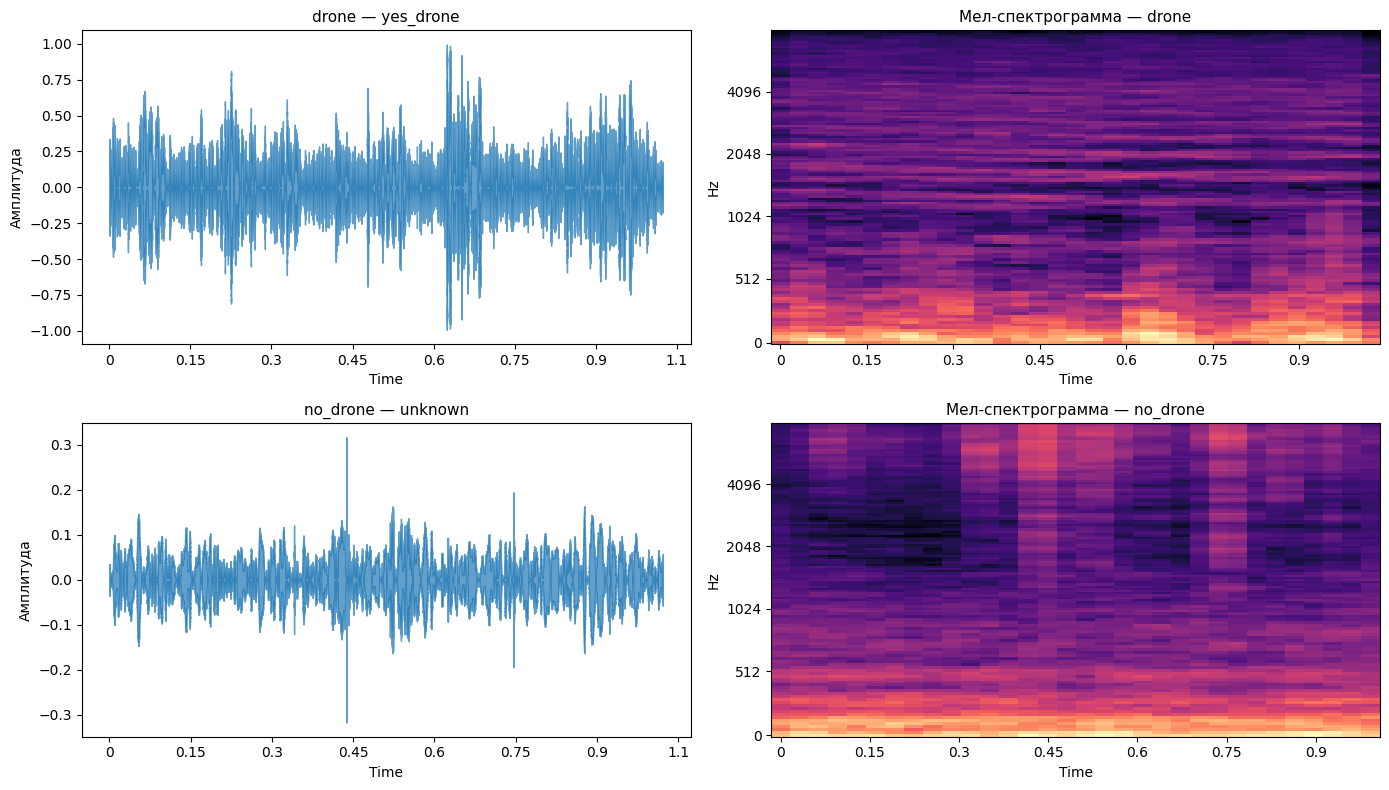

In [8]:
# ============================================================
# Визуализация: осциллограмма + мел-спектрограмма
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, label in enumerate([1, 0]):
    subset = df[df['label'] == label]
    if len(subset) == 0:
        continue
    sample = subset.iloc[0]
    y, sr = librosa.load(sample['path'], sr=SAMPLE_RATE, duration=DURATION)
    
    # Осциллограмма
    ax = axes[row, 0]
    librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.7)
    ax.set_title(f'{LABEL_NAMES[label]} — {sample["class_name"]}', fontsize=11)
    ax.set_ylabel('Амплитуда')
    
    # Мел-спектрограмма
    ax = axes[row, 1]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                       n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'Мел-спектрограмма — {LABEL_NAMES[label]}', fontsize=11)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'audio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# Прослушать примеры
# ============================================================

for label in df['label'].unique():
    subset = df[df['label'] == label]
    if len(subset) == 0:
        continue
    sample_row = subset.iloc[0]
    try:
        y, sr = librosa.load(sample_row['path'], sr=SAMPLE_RATE, duration=3)
        print(f'\n🔊 {LABEL_NAMES.get(label, label)} ({sample_row["class_name"]}):')
        display(Audio(y, rate=sr))
    except Exception as e:
        print(f'   ⚠️ Ошибка: {e}')


🔊 no_drone (unknown):



🔊 drone (yes_drone):


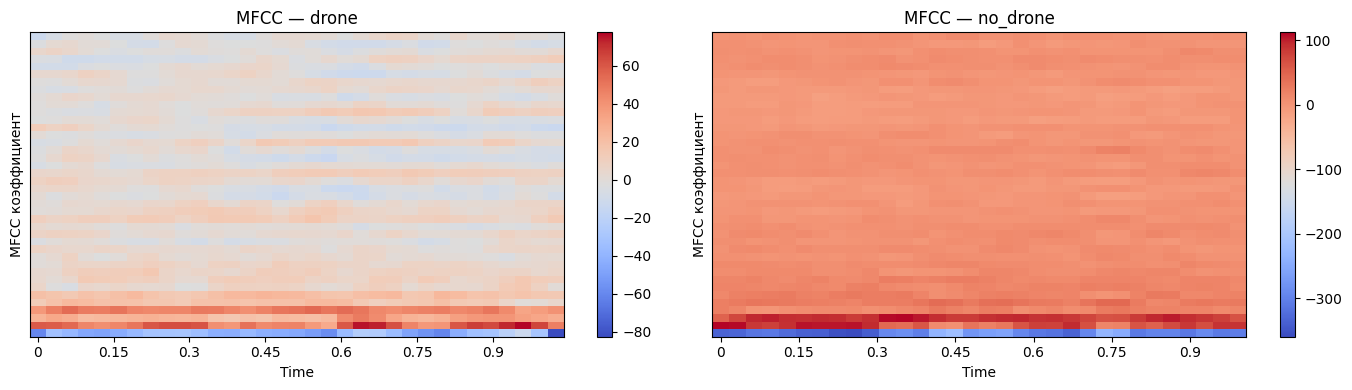

In [10]:
# ============================================================
# MFCC визуализация
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, label in enumerate([1, 0]):
    subset = df[df['label'] == label]
    if len(subset) == 0:
        continue
    sample = subset.iloc[0]
    y, sr = librosa.load(sample['path'], sr=SAMPLE_RATE, duration=DURATION)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH)
    ax = axes[i]
    img = librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LENGTH,
                                    x_axis='time', ax=ax)
    ax.set_title(f'MFCC — {LABEL_NAMES[label]}', fontsize=12)
    ax.set_ylabel('MFCC коэффициент')
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'mfcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Извлечение признаков

In [11]:
def load_and_pad(filepath, sr=SAMPLE_RATE, duration=DURATION):
    """Загрузить аудио и привести к фиксированной длине."""
    try:
        y, _ = librosa.load(filepath, sr=sr, mono=True)
    except Exception:
        return np.zeros(int(sr * duration))
    
    target_len = int(sr * duration)
    if len(y) >= target_len:
        start = np.random.randint(0, len(y) - target_len + 1)
        y = y[start:start + target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)))
    return y


def extract_mel_spectrogram(y, sr=SAMPLE_RATE):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                       n_fft=N_FFT, hop_length=HOP_LENGTH)
    return librosa.power_to_db(S, ref=np.max)


def extract_mfcc(y, sr=SAMPLE_RATE):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.stack([mfcc, delta, delta2])


# Проверка размеров
test_y = load_and_pad(df.iloc[0]['path'])
test_mel = extract_mel_spectrogram(test_y)
test_mfcc = extract_mfcc(test_y)
print(f'✅ Мел-спектрограмма: {test_mel.shape}')
print(f'   MFCC (3-канальный): {test_mfcc.shape}')

✅ Мел-спектрограмма: (128, 94)
   MFCC (3-канальный): (3, 40, 94)


---
## 5. Dataset и DataLoader

In [12]:
class DroneAudioDataset(Dataset):
    def __init__(self, filepaths, labels, feature_type='mel',
                 sr=SAMPLE_RATE, duration=DURATION, augment=False):
        self.filepaths = filepaths
        self.labels = labels
        self.feature_type = feature_type
        self.sr = sr
        self.duration = duration
        self.augment = augment
    
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]
        
        y = load_and_pad(filepath, self.sr, self.duration)
        
        # Аугментация
        if self.augment:
            if np.random.rand() < 0.5:
                y = y * np.random.uniform(0.7, 1.3)
            if np.random.rand() < 0.3:
                y = y + np.random.randn(len(y)) * 0.005
            if np.random.rand() < 0.3:
                y = np.roll(y, np.random.randint(-1600, 1600))
        
        # Признаки
        if self.feature_type == 'mel':
            features = extract_mel_spectrogram(y, self.sr)
            features = features[np.newaxis, ...]  # (1, n_mels, time)
        elif self.feature_type == 'mfcc':
            features = extract_mfcc(y, self.sr)    # (3, n_mfcc, time)
        else:
            raise ValueError(f'Unknown feature_type: {self.feature_type}')
        
        # Нормализация
        features = (features - features.mean()) / (features.std() + 1e-8)
        
        return torch.FloatTensor(features), torch.LongTensor([label]).squeeze()


print('✅ DroneAudioDataset готов')

✅ DroneAudioDataset готов


In [13]:
# ============================================================
# Split: train / val / test
# ============================================================

train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'],
                                      random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.18, stratify=train_df['label'],
                                     random_state=SEED)

print(f'📊 Split:')
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    d = split_df['label'].value_counts().to_dict()
    print(f'   {name:5s}: {len(split_df):5d}  (drone={d.get(1,0)}, no_drone={d.get(0,0)})')

FEATURE_TYPE = 'mel'  # 'mel' или 'mfcc'

train_dataset = DroneAudioDataset(
    train_df['path'].tolist(), train_df['label'].tolist(),
    feature_type=FEATURE_TYPE, augment=True)
val_dataset = DroneAudioDataset(
    val_df['path'].tolist(), val_df['label'].tolist(),
    feature_type=FEATURE_TYPE, augment=False)
test_dataset = DroneAudioDataset(
    test_df['path'].tolist(), test_df['label'].tolist(),
    feature_type=FEATURE_TYPE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

batch_x, batch_y = next(iter(train_loader))
print(f'\n   Batch shape: {batch_x.shape}')
print(f'   Labels:      {batch_y[:8].tolist()}')

📊 Split:
   Train:  1856  (drone=928, no_drone=928)
   Val  :   408  (drone=204, no_drone=204)
   Test :   400  (drone=200, no_drone=200)

   Batch shape: torch.Size([32, 1, 128, 94])
   Labels:      [0, 0, 0, 1, 1, 0, 1, 1]


---
## 6. Архитектуры моделей

In [14]:
# ============================================================
# Модель 1: AudioCNN
# ============================================================

class AudioCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.3),
            
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))


# ============================================================
# Модель 2: AudioCRNN (Conv + BiLSTM)
# ============================================================

class AudioCRNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2, hidden_size=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),
        )
        self.lstm = nn.LSTM(
            input_size=128 * (N_MELS // 8),
            hidden_size=hidden_size, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )
    
    def forward(self, x):
        x = self.cnn(x)
        b, c, f, t = x.shape
        x = x.permute(0, 3, 1, 2).reshape(b, t, c * f)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.classifier(x)


# ============================================================
# Модель 3: AudioResNet
# ============================================================

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch),
        )
    def forward(self, x):
        return F.relu(self.block(x) + x)


class AudioResNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = nn.Sequential(ResBlock(64), ResBlock(64))
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            ResBlock(128),
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            ResBlock(256),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        return self.head(self.layer3(self.layer2(self.layer1(self.stem(x)))))


# Проверка
for name, Cls in [('AudioCNN', AudioCNN), ('AudioCRNN', AudioCRNN), ('AudioResNet', AudioResNet)]:
    m = Cls(in_channels=1, num_classes=2)
    p = sum(p.numel() for p in m.parameters())
    o = m(batch_x[:2])
    print(f'   {name:12s}: {p/1e3:.1f}K params, output={o.shape}')

   AudioCNN    : 1632.4K params, output=torch.Size([2, 2])
   AudioCRNN   : 2735.2K params, output=torch.Size([2, 2])
   AudioResNet : 1998.7K params, output=torch.Size([2, 2])


---
## 7. Обучение

In [15]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS,
                lr=LEARNING_RATE, patience=PATIENCE, model_name='model'):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0.0
    patience_counter = 0
    best_state = None
    
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for bx, by in train_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * bx.size(0)
            correct += (out.argmax(1) == by).sum().item()
            total += by.size(0)
        scheduler.step()
        train_loss /= total
        train_acc = correct / total
        
        # VAL
        model.eval()
        val_loss_sum, preds, labels = 0.0, [], []
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                out = model(bx)
                val_loss_sum += criterion(out, by).item() * bx.size(0)
                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(by.cpu().numpy())
        
        val_loss = val_loss_sum / len(labels)
        val_acc = accuracy_score(labels, preds)
        val_f1 = f1_score(labels, preds, average='macro')
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), MODEL_DIR / f'{model_name}_best.pt')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} │ '
                  f'loss={train_loss:.4f} acc={train_acc:.4f} │ '
                  f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} F1={val_f1:.4f}')
        
        if patience_counter >= patience:
            print(f'  ⏹️  Early stopping на эпохе {epoch+1}')
            break
    
    if best_state:
        model.load_state_dict(best_state)
        model = model.to(DEVICE)
    
    print(f'  ✅ Лучший val F1: {best_val_f1:.4f}')
    return model, history

In [16]:
print('🚀 Обучение AudioCNN...')
print('='*70)
cnn_model = AudioCNN(in_channels=1, num_classes=2)
cnn_model, cnn_history = train_model(cnn_model, train_loader, val_loader, model_name='audio_cnn')

🚀 Обучение AudioCNN...
  Epoch   1/50 │ loss=0.5258 acc=0.7484 │ val_loss=0.3514 val_acc=0.8284 F1=0.8260
  Epoch   5/50 │ loss=0.2200 acc=0.9235 │ val_loss=0.1970 val_acc=0.9167 F1=0.9162
  Epoch  10/50 │ loss=0.1230 acc=0.9564 │ val_loss=0.0988 val_acc=0.9583 F1=0.9583
  Epoch  15/50 │ loss=0.0980 acc=0.9628 │ val_loss=0.0781 val_acc=0.9657 F1=0.9657
  Epoch  20/50 │ loss=0.0454 acc=0.9811 │ val_loss=0.0799 val_acc=0.9681 F1=0.9681
  Epoch  25/50 │ loss=0.0333 acc=0.9871 │ val_loss=0.0985 val_acc=0.9730 F1=0.9730
  Epoch  30/50 │ loss=0.0310 acc=0.9903 │ val_loss=0.0685 val_acc=0.9828 F1=0.9828
  ⏹️  Early stopping на эпохе 31
  ✅ Лучший val F1: 0.9828


In [17]:
print('\n🚀 Обучение AudioCRNN...')
print('='*70)
crnn_model = AudioCRNN(in_channels=1, num_classes=2)
crnn_model, crnn_history = train_model(crnn_model, train_loader, val_loader, model_name='audio_crnn')


🚀 Обучение AudioCRNN...
  Epoch   1/50 │ loss=0.6450 acc=0.6202 │ val_loss=0.6546 val_acc=0.6054 F1=0.5326
  Epoch   5/50 │ loss=0.4531 acc=0.8179 │ val_loss=0.4563 val_acc=0.8284 F1=0.8281
  Epoch  10/50 │ loss=0.2179 acc=0.9246 │ val_loss=0.2703 val_acc=0.8946 F1=0.8936
  Epoch  15/50 │ loss=0.1676 acc=0.9456 │ val_loss=0.1789 val_acc=0.9461 F1=0.9460
  Epoch  20/50 │ loss=0.1288 acc=0.9601 │ val_loss=0.1573 val_acc=0.9534 F1=0.9534
  Epoch  25/50 │ loss=0.0774 acc=0.9693 │ val_loss=0.0947 val_acc=0.9657 F1=0.9657
  Epoch  30/50 │ loss=0.0646 acc=0.9860 │ val_loss=0.0646 val_acc=0.9804 F1=0.9804
  Epoch  35/50 │ loss=0.0482 acc=0.9898 │ val_loss=0.0415 val_acc=0.9877 F1=0.9877
  Epoch  40/50 │ loss=0.0397 acc=0.9914 │ val_loss=0.0593 val_acc=0.9853 F1=0.9853
  Epoch  45/50 │ loss=0.0258 acc=0.9941 │ val_loss=0.0623 val_acc=0.9877 F1=0.9877
  Epoch  50/50 │ loss=0.0238 acc=0.9935 │ val_loss=0.0643 val_acc=0.9853 F1=0.9853
  ✅ Лучший val F1: 0.9902


In [18]:
print('\n🚀 Обучение AudioResNet...')
print('='*70)
resnet_model = AudioResNet(in_channels=1, num_classes=2)
resnet_model, resnet_history = train_model(resnet_model, train_loader, val_loader, model_name='audio_resnet')


🚀 Обучение AudioResNet...
  Epoch   1/50 │ loss=0.3999 acc=0.8206 │ val_loss=0.9353 val_acc=0.5245 F1=0.3856
  Epoch   5/50 │ loss=0.1905 acc=0.9240 │ val_loss=0.2335 val_acc=0.8995 F1=0.8985
  Epoch  10/50 │ loss=0.1283 acc=0.9483 │ val_loss=0.2482 val_acc=0.9191 F1=0.9186
  Epoch  15/50 │ loss=0.1061 acc=0.9617 │ val_loss=0.0631 val_acc=0.9706 F1=0.9706
  Epoch  20/50 │ loss=0.0591 acc=0.9779 │ val_loss=0.0920 val_acc=0.9681 F1=0.9681
  Epoch  25/50 │ loss=0.0365 acc=0.9871 │ val_loss=0.0638 val_acc=0.9755 F1=0.9755
  Epoch  30/50 │ loss=0.0323 acc=0.9914 │ val_loss=0.0929 val_acc=0.9755 F1=0.9755
  ⏹️  Early stopping на эпохе 32
  ✅ Лучший val F1: 0.9804


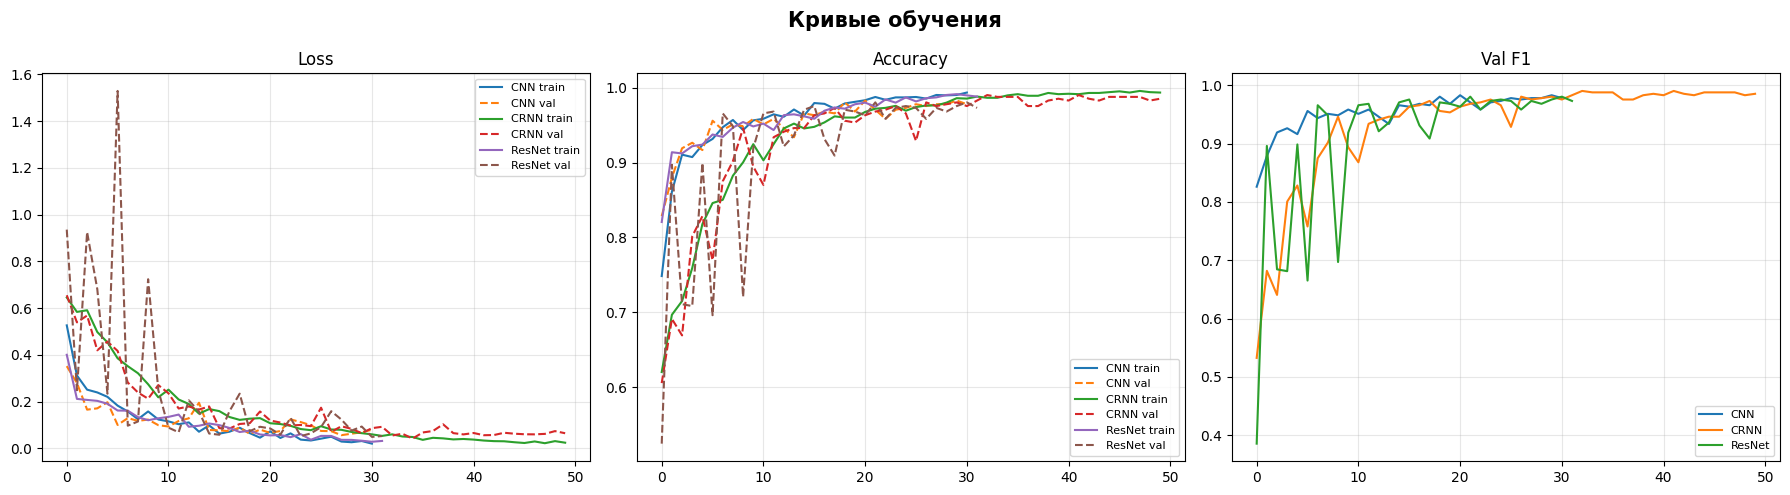

In [19]:
# ============================================================
# Кривые обучения
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
names = ['CNN', 'CRNN', 'ResNet']
histories = [cnn_history, crnn_history, resnet_history]

for h, n in zip(histories, names):
    axes[0].plot(h['train_loss'], label=f'{n} train')
    axes[0].plot(h['val_loss'], '--', label=f'{n} val')
axes[0].set_title('Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for h, n in zip(histories, names):
    axes[1].plot(h['train_acc'], label=f'{n} train')
    axes[1].plot(h['val_acc'], '--', label=f'{n} val')
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

for h, n in zip(histories, names):
    axes[2].plot(h['val_f1'], label=n)
axes[2].set_title('Val F1'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Кривые обучения', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Оценка и визуализация

In [20]:
def evaluate_model(model, test_loader, model_name='Model'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(DEVICE)
            out = model(bx)
            probs = F.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(by.numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0
    
    print(f'\n{"="*50}')
    print(f'📊 {model_name} — Тестовая выборка')
    print(f'{"="*50}')
    print(f'   Accuracy:  {acc:.4f}')
    print(f'   F1 (macro): {f1:.4f}')
    print(f'   AUC-ROC:   {auc:.4f}')
    print(classification_report(all_labels, all_preds, target_names=list(LABEL_NAMES.values())))
    
    return {'model': model_name, 'accuracy': acc, 'f1': f1, 'auc': auc,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}


cnn_results = evaluate_model(cnn_model, test_loader, 'AudioCNN')
crnn_results = evaluate_model(crnn_model, test_loader, 'AudioCRNN')
resnet_results = evaluate_model(resnet_model, test_loader, 'AudioResNet')


📊 AudioCNN — Тестовая выборка
   Accuracy:  0.9725
   F1 (macro): 0.9725
   AUC-ROC:   0.9959
              precision    recall  f1-score   support

    no_drone       0.98      0.96      0.97       200
       drone       0.97      0.98      0.97       200

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400


📊 AudioCRNN — Тестовая выборка
   Accuracy:  0.9725
   F1 (macro): 0.9725
   AUC-ROC:   0.9939
              precision    recall  f1-score   support

    no_drone       0.98      0.96      0.97       200
       drone       0.97      0.98      0.97       200

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400


📊 AudioResNet — Тестовая выборка
   Accuracy:  0.9750
   F1 (macro): 0.9750
   AUC-ROC:   0.9982
              precision    recall  f1-score   support

  

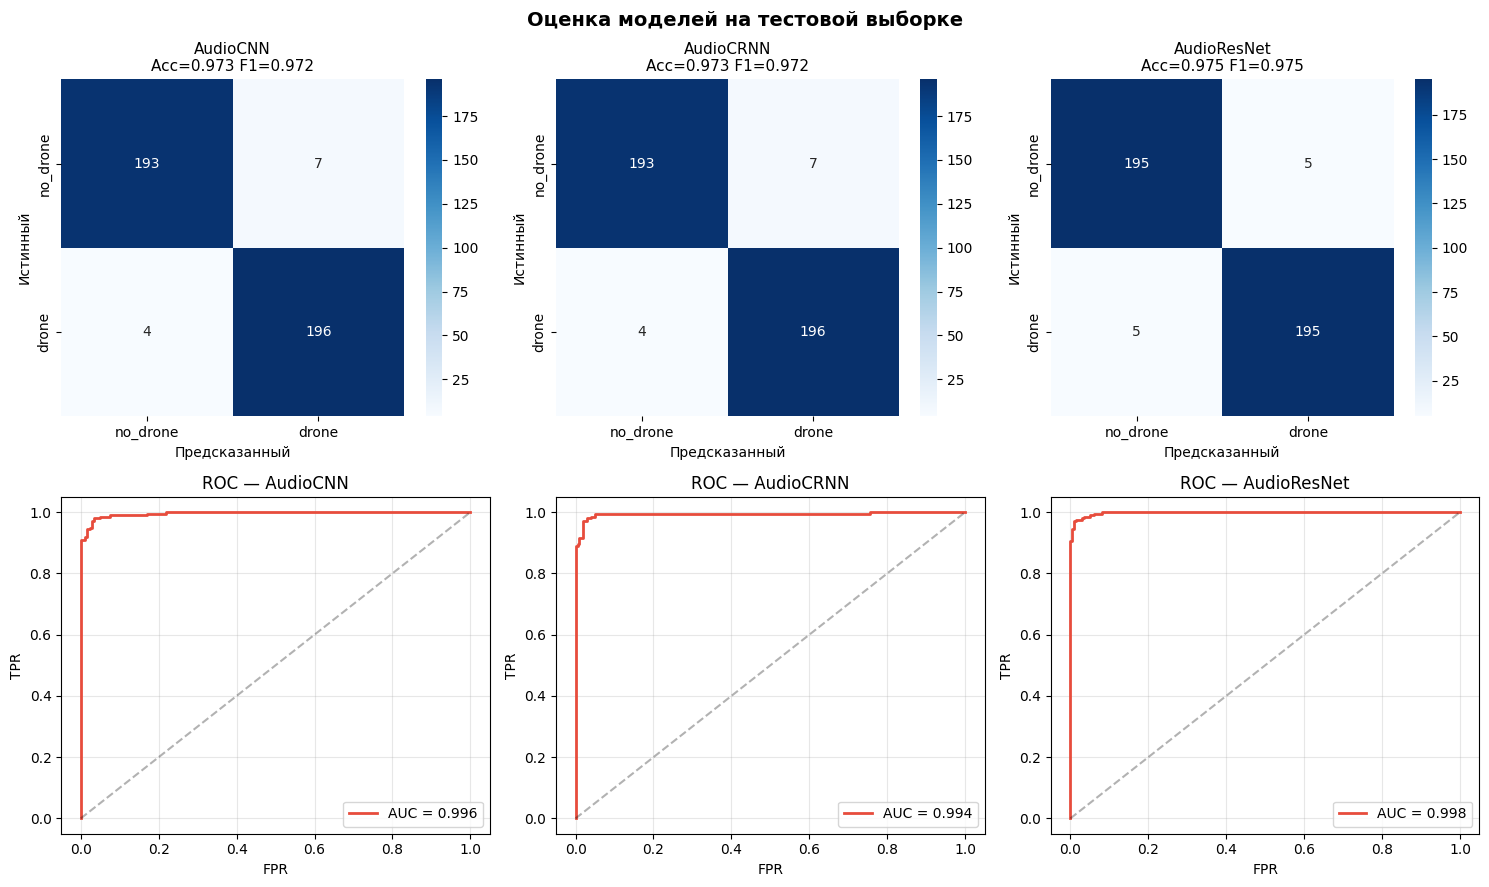

In [21]:
# ============================================================
# Confusion Matrix + ROC
# ============================================================

all_results = [cnn_results, crnn_results, resnet_results]
n = len(all_results)

fig, axes = plt.subplots(2, n, figsize=(5*n, 9))

for i, res in enumerate(all_results):
    # Confusion matrix
    ax = axes[0, i]
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=list(LABEL_NAMES.values()),
                yticklabels=list(LABEL_NAMES.values()))
    ax.set_title(f"{res['model']}\nAcc={res['accuracy']:.3f} F1={res['f1']:.3f}", fontsize=11)
    ax.set_ylabel('Истинный'); ax.set_xlabel('Предсказанный')
    
    # ROC
    ax = axes[1, i]
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f"AUC = {res['auc']:.3f}")
    ax.plot([0,1], [0,1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f"ROC — {res['model']}"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Оценка моделей на тестовой выборке', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR / 'evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Сравнение моделей

In [22]:
def benchmark_inference(model, n_runs=100):
    model.eval()
    dummy = torch.randn(1, 1, N_MELS, 94).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): model(dummy)  # warmup
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(dummy)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000


comparison = []
for model, res, name in [
    (cnn_model, cnn_results, 'AudioCNN'),
    (crnn_model, crnn_results, 'AudioCRNN'),
    (resnet_model, resnet_results, 'AudioResNet'),
]:
    params = sum(p.numel() for p in model.parameters())
    lat = benchmark_inference(model)
    comparison.append({
        'Модель': name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1 (macro)': f"{res['f1']:.4f}",
        'AUC-ROC': f"{res['auc']:.4f}",
        'Latency (ms)': f'{lat:.1f}',
        'Params (K)': f'{params/1e3:.1f}',
    })

cmp_df = pd.DataFrame(comparison)
print('\n📊 Сравнение моделей:')
display(cmp_df.style.set_caption('Результаты на тестовой выборке'))
cmp_df.to_csv(VIZ_DIR / 'model_comparison.csv', index=False)


📊 Сравнение моделей:


,Модель,Accuracy,F1 (macro),AUC-ROC,Latency (ms),Params (K)
0,AudioCNN,0.9725,0.9725,0.9959,10.3,1632.4
1,AudioCRNN,0.9725,0.9725,0.9939,17.1,2735.2
2,AudioResNet,0.9750,0.9750,0.9982,7.4,1998.7


---
## 10. Экспорт результатов

In [23]:
best_idx = int(np.argmax([cnn_results['f1'], crnn_results['f1'], resnet_results['f1']]))
best_names = ['AudioCNN', 'AudioCRNN', 'AudioResNet']
best_res = [cnn_results, crnn_results, resnet_results][best_idx]

summary = {
    'task': 'Бинарная классификация: дрон vs не-дрон (аудио)',
    'dataset': 'DroneAudioDataset (Al-Emadi et al.)',
    'features': f'Mel-spectrogram ({N_MELS} mels, FFT={N_FFT}, hop={HOP_LENGTH})',
    'audio_params': f'{SAMPLE_RATE}Hz, {DURATION}s segments',
    'balancing': 'Undersampling majority class',
    'best_model': best_names[best_idx],
    'best_accuracy': f"{best_res['accuracy']:.4f}",
    'best_f1': f"{best_res['f1']:.4f}",
    'best_auc': f"{best_res['auc']:.4f}",
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
}

print('\n' + '='*50)
print('📋 СВОДКА ДЛЯ ВКР (аудио-модуль)')
print('='*50)
for k, v in summary.items():
    print(f'  {k:20s}: {v}')

with open(VIZ_DIR / 'audio_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'\n💾 Сводка: {VIZ_DIR / "audio_summary.json"}')


📋 СВОДКА ДЛЯ ВКР (аудио-модуль)
  task                : Бинарная классификация: дрон vs не-дрон (аудио)
  dataset             : DroneAudioDataset (Al-Emadi et al.)
  features            : Mel-spectrogram (128 mels, FFT=2048, hop=512)
  audio_params        : 16000Hz, 3.0s segments
  balancing           : Undersampling majority class
  best_model          : AudioResNet
  best_accuracy       : 0.9750
  best_f1             : 0.9750
  best_auc            : 0.9982
  train_samples       : 1856
  val_samples         : 408
  test_samples        : 400

💾 Сводка: /kaggle/working/visualizations/audio_summary.json


In [24]:
print('\n📥 Артефакты:')
print('='*50)
for path, desc in [
    (MODEL_DIR / 'audio_cnn_best.pt', 'CNN веса'),
    (MODEL_DIR / 'audio_crnn_best.pt', 'CRNN веса'),
    (MODEL_DIR / 'audio_resnet_best.pt', 'ResNet веса'),
    (VIZ_DIR / 'audio_comparison.png', 'Сравнение аудио'),
    (VIZ_DIR / 'mfcc_comparison.png', 'MFCC визуализация'),
    (VIZ_DIR / 'training_curves.png', 'Кривые обучения'),
    (VIZ_DIR / 'evaluation_results.png', 'Результаты оценки'),
    (VIZ_DIR / 'model_comparison.csv', 'Таблица сравнения'),
    (VIZ_DIR / 'audio_summary.json', 'Сводка метрик'),
]:
    if Path(path).exists():
        print(f'  ✅ {desc:25s} — {Path(path).name} ({Path(path).stat().st_size/1e3:.1f} KB)')
    else:
        print(f'  ⬜ {desc:25s} — не найден')

print(f'\n   На Kaggle: Output → Download All')


📥 Артефакты:
  ✅ CNN веса                  — audio_cnn_best.pt (6552.8 KB)
  ✅ CRNN веса                 — audio_crnn_best.pt (10956.3 KB)
  ✅ ResNet веса               — audio_resnet_best.pt (8033.1 KB)
  ✅ Сравнение аудио           — audio_comparison.png (352.1 KB)
  ✅ MFCC визуализация         — mfcc_comparison.png (49.9 KB)
  ✅ Кривые обучения           — training_curves.png (234.2 KB)
  ✅ Результаты оценки         — evaluation_results.png (126.0 KB)
  ✅ Таблица сравнения         — model_comparison.csv (0.2 KB)
  ✅ Сводка метрик             — audio_summary.json (0.5 KB)

   На Kaggle: Output → Download All
